#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

In [ ]:
import os
csv_files = [
    f for f in os.listdir('/content')
    if f.endswith('.csv')
]
print(csv_files)

['xAPI-Edu-Data.csv', 'cleaned_dataset.csv']


#Load The Dataset

In [ ]:
df = pd.read_csv('xAPI-Edu-Data.csv')
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


#Basic Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [ ]:
df.shape

(480, 17)

In [ ]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [ ]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


#Checking Missing Values

In [ ]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


#Checking Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(2)

#Removing Duplicates

In [ ]:
df= df.drop_duplicates()

#EDA
(Visualization 1: Student Performance distribution)

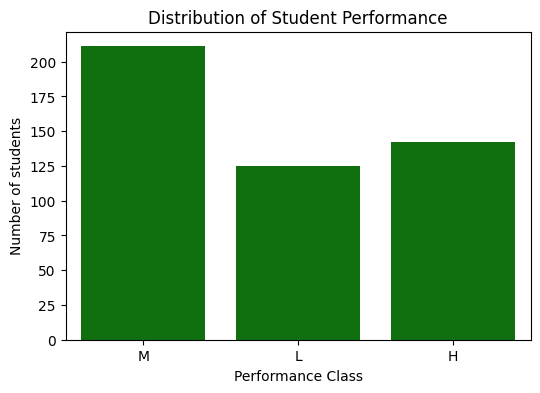

In [ ]:
plt.figure(figsize = (6,4))
sns.countplot(x = 'Class', data = df, color = 'green')
plt.title("Distribution of Student Performance")
plt.xlabel("Performance Class")
plt.ylabel("Number of students")
plt.savefig('Student_performance.png')
plt.show()

Visualization 2: Gender Distribution

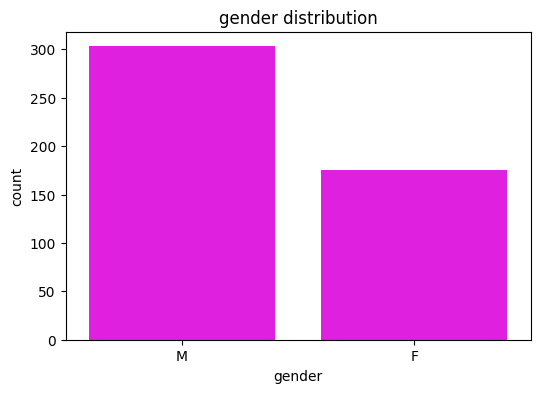

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x = 'gender', data = df, color = 'magenta')
plt.title('gender distribution')
plt.xlabel('gender')
plt.ylabel('count')
plt.savefig('gender_distribution.png')
plt.show()

Visualisation 3: student absence days

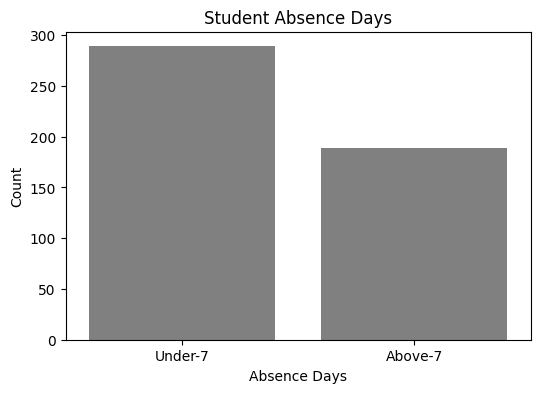

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='StudentAbsenceDays', data=df, color = 'grey')
plt.title("Student Absence Days")
plt.xlabel("Absence Days")
plt.ylabel("Count")
plt.savefig('student_absencedays.png')
plt.show()

Visualisation 4: raised hands vs performance

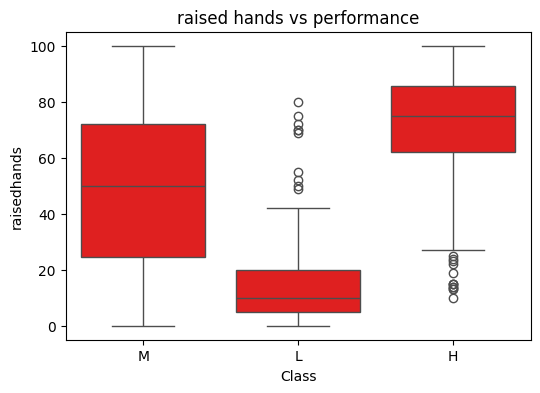

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x = 'Class', y = 'raisedhands', data = df, color = "Red")
plt.title("raised hands vs performance")
plt.savefig('comparison.png')
plt.show()

Visualization 5: Visited resources vs performance

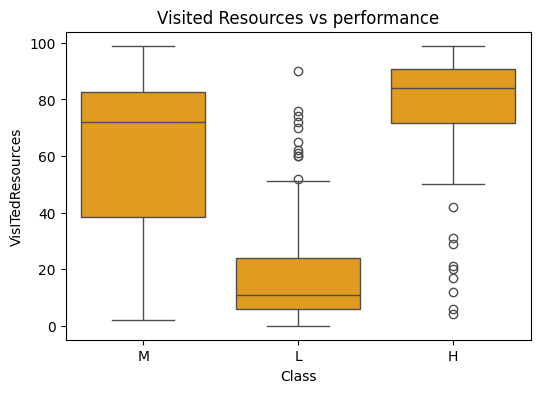

In [ ]:
plt.figure(figsize = (6,4))
sns.boxplot(x= 'Class', y= 'VisITedResources', data = df, color = "orange")
plt.title("Visited Resources vs performance")
plt.savefig('resources_performances.png')
plt.show()

Visualization 6: correlation Heatmap

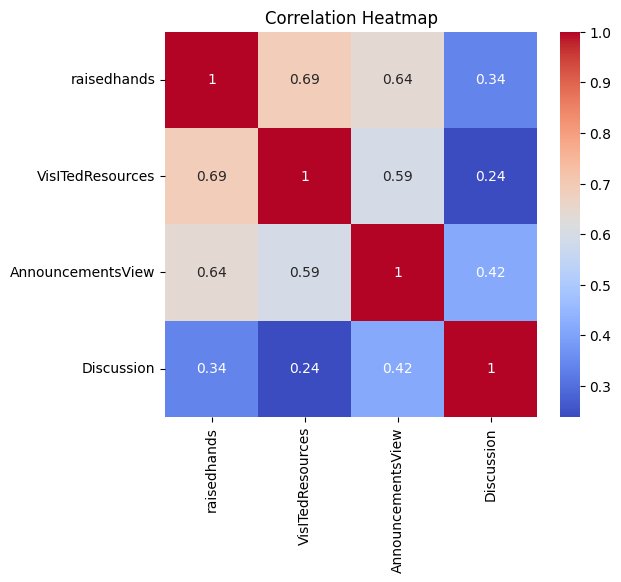

In [ ]:
plt.figure(figsize=(6,5))
numeric_df = df.select_dtypes(include=['int64'])
sns.heatmap(numeric_df.corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.savefig('correlation_heatmap.png')
plt.show()

#Data preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for column in df.columns:
  if df[column].dtype == 'object':
    df[column] = le.fit_transform(df[column])
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,4,4,2,1,0,7,0,0,15,16,2,20,1,1,1,2
1,1,4,4,2,1,0,7,0,0,20,20,3,25,1,1,1,2
2,1,4,4,2,1,0,7,0,0,10,7,0,30,0,0,0,1
3,1,4,4,2,1,0,7,0,0,30,25,5,35,0,0,0,1
4,1,4,4,2,1,0,7,0,0,40,50,12,50,0,0,0,2


#Defining the feature(x) and target (y)

In [ ]:
x = df.drop('Class', axis = 1)
y = df['Class']

#Splitting The Dataset

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 42)

#Training & Predicting The Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state = 42)
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(x_test)

#Model Evaluation
(Calculating the accuracy)

---



In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6458333333333334


Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.67      0.58        24
           1       0.77      0.85      0.81        27
           2       0.66      0.51      0.57        45

    accuracy                           0.65        96
   macro avg       0.65      0.68      0.65        96
weighted avg       0.65      0.65      0.64        96



Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[16  0  8]
 [ 0 23  4]
 [15  7 23]]


Visualization of the confusion matrix

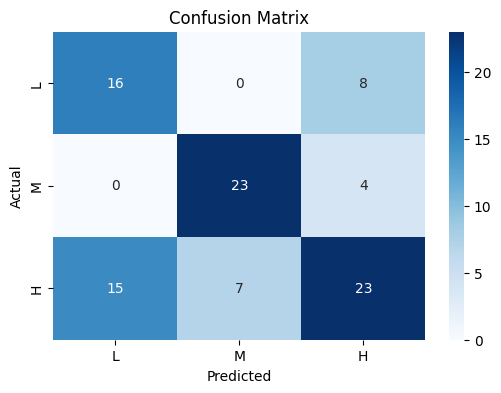

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'Blues', xticklabels =['L','M','H'], yticklabels = ['L','M','H'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()

#Saving the cleaned dataset

In [ ]:
df.to_csv("cleaned_dataset.csv", index = False)

#Feature Importance

                     Feature  Importance
10          VisITedResources    0.240429
15        StudentAbsenceDays    0.197878
9                raisedhands    0.127770
12                Discussion    0.097949
11         AnnouncementsView    0.082639
13     ParentAnsweringSurvey    0.062013
6                      Topic    0.036970
8                   Relation    0.036586
4                    GradeID    0.026900
0                     gender    0.025286
2               PlaceofBirth    0.017543
3                    StageID    0.014366
1                NationalITy    0.011502
14  ParentschoolSatisfaction    0.011428
5                  SectionID    0.010741
7                   Semester    0.000000


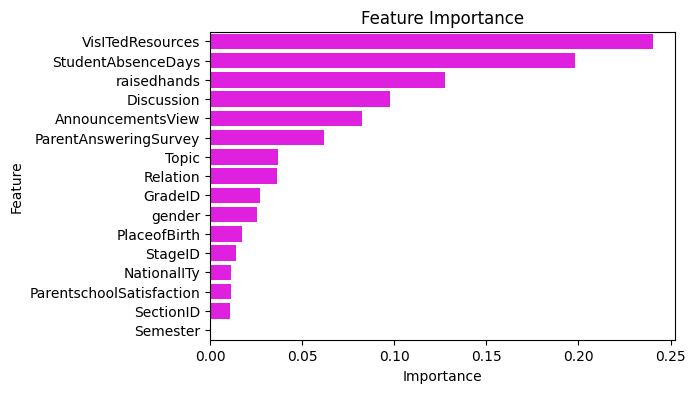

In [ ]:
feature_importance = pd.DataFrame({'Feature': x.columns, 'Importance': model.feature_importances_})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)
print(feature_importance)
plt.figure(figsize= (6,4))
sns.barplot(x = 'Importance', y = 'Feature', data = feature_importance, color = 'magenta')
plt.title('Feature Importance')
plt.savefig('Feature_importance.png')
plt.show()


#Insights and Conclusion

##Model Performance
The Decision Tree Classifier was trained to predict student acacdemic performance based on demographic, academic and behavioral features. The achieved an accuracy of 64.58% on the test dataset.

##Feature Importance
The feature importance analysis reveaked that the most influential factors affcting student performance were:
- VisITedResources
- StudentAbsenceDays
- raisedhands
- Discussion
- AnnouncementView
These features contributed the most to the model's predictions.

##Key Insights
- Students who accessed learning resources more frequently tended to achieve better academic performance.
- Regular attendence played an important role in student success, as students with fewer absence days generally performed better.
- Active classroom participation, measured by raised hands and discusiion participation, positively influenced academic performance.
- Students who regularly viewed course announcements were more engaged and were more likely to perform well.
- Behavioral and engagement related features had a greater influence on academic performance than demographic features such as gender or nationality.

##Conclusion
This project successfully demonstrated an end-to-end machine learning workflow for predicting student academic performance. The Decision Tree model identified meaning patterns in the dataset and highlighted the importance of attendence, classroom participation and learning resouce usage. Such predictive models can assist educational institutions in identifying students who may bebefit from additional academic support.